In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from model import ConvAttnPool

In [3]:
import matplotlib.pyplot as plt
import numpy             as np
import pandas            as pd

from IPython import display
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import json
import time

from   torch.utils.data    import DataLoader, TensorDataset
import torch.nn.functional as F
import torch.nn            as nn
import os
import torch
from gensim.models import Word2Vec

import random

default_path  = os.getcwd()
print(default_path)

torch.manual_seed(seed = 42)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# device = torch.device('cpu')
print(device)

/home/drew/FL-with-MIMIC/Replicating Mullenbach
cuda


In [4]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

In [5]:
def time_it(func):
    def wrapper(*arg, **kw):
        t1 = time.time()
        res = func(*arg, **kw)
        t2 = time.time()
        secs = (t2 - t1)
        print(f'Runtime: {secs:.3f}s')
        return res
    return wrapper

In [6]:
from sklearn.metrics import classification_report
from evaluation      import all_metrics
from pprint          import pprint

@torch.no_grad()
def eval_model(model, device, data_loader,label_space):
    model.eval()
    all_pred     = torch.empty((0,), dtype = torch.float32).to(device)
    all_labels   = torch.empty((0,), dtype = torch.float32).to(device)
    all_pred_raw = torch.empty((0,), dtype = torch.float32).to(device)

    for data_inputs, data_labels in data_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)
        preds, _    = model(data_inputs)
        pred_labels = (F.sigmoid(preds) >= 0.5).long()

        all_pred     = torch.cat((all_pred,pred_labels), dim = 0 )
        all_labels   = torch.cat((all_labels,data_labels), dim = 0)
        all_pred_raw = torch.cat([all_pred_raw, preds], dim = 0)

    #print(classification_report(y_pred =   all_pred.cpu().numpy(), y_true = all_labels.cpu().numpy()))
    return (all_metrics(yhat =   all_pred.cpu().numpy(), y = all_labels.cpu().numpy(), yhat_raw=all_pred_raw.cpu().numpy()  ))

### Load in our dataset from PreProcessing.ipynb

In [7]:
X_train = np.load('X_train.npy')
X_test  = np.load('X_test.npy')

Y_train = np.load('Y_train.npy')
Y_test  = np.load('Y_test.npy')

### Convvert to DataLoader (Pytorch)

In [8]:
X_train = torch.from_numpy(X_train).long()
Y_train = torch.from_numpy(Y_train).type(torch.float32)

X_test  = torch.from_numpy(X_test) .long()
Y_test  = torch.from_numpy(Y_test) .type(torch.float32)

train_loader = DataLoader(TensorDataset(X_train,Y_train) , batch_size = 16, shuffle = False)
test_loader  = DataLoader(TensorDataset(X_test ,Y_test ) , batch_size = 64 , shuffle = False)

In [9]:
X_train.shape , X_test.shape

(torch.Size([8066, 2500]), torch.Size([1729, 2500]))

In [17]:
model = Word2Vec.load('processed_full.w2v')
vocab_size, embed_size = model.wv.vectors.shape
print(f'{vocab_size=}', f'{embed_size=}')
embedding_table = torch.from_numpy(model.wv.vectors).type(torch.float32)
embedding_table = torch.concat([embedding_table,torch.zeros(size = (1,embed_size))], dim = 0)
print(f'{vocab_size=}', f'{embed_size=}') # Keep the since vocab_size refers to the last index, our padding index)

vocab_size=150853 embed_size=100
vocab_size=150853 embed_size=100


In [18]:
cancer_idx = model.wv.key_to_index['cancer']
print(model.wv[cancer_idx][:5])
print(embedding_table[cancer_idx][:5])

[-1.1495988  -0.28078428  3.3482153  -4.63497     0.86195445]
tensor([-1.1496, -0.2808,  3.3482, -4.6350,  0.8620])


In [12]:
model = ConvAttnPool(
            drop_out       = 0.2,
            embed_table   = embedding_table,
            vocab_size    = vocab_size,
            num_of_filters = 15, # Filters in paper -> 10
            label_space    = 50, 
            kernel_size    = 5,
            embed_d        = embed_size)
model.to(device=device)

ConvAttnPool(
  (embed): Embedding(150854, 100, padding_idx=150853)
  (conv): Conv1d(100, 15, kernel_size=(5,), stride=(1,), padding=(2,))
  (U): Linear(in_features=15, out_features=50, bias=True)
  (final): Linear(in_features=15, out_features=50, bias=True)
  (embed_drop): Dropout(p=0.2, inplace=False)
)

In [14]:
eval_model(model        = model,
           device       = device,
           label_space  = 50,
           data_loader  = train_loader)

eval_model(model        = model,
           device       = device,
           label_space  = 50,
           data_loader  = test_loader)

{'acc_macro': 0.0667301959521219,
 'prec_macro': 0.08324095025735176,
 'rec_macro': 0.5216147463823488,
 'f1_macro': 0.143570466140384,
 'acc_micro': 0.10099930741070545,
 'prec_micro': 0.11301536690137727,
 'rec_micro': 0.4871623556361554,
 'f1_micro': 0.1834684304175129,
 'rec_at_8': 0.1441683166570895,
 'prec_at_8': 0.10287738577212262,
 'f1_at_8': 0.12007219217341986,
 'auc_macro': 0.4836944290637762,
 'auc_micro': 0.46297539286074896}

In [19]:
# @time_it
def train_model(model,device, optimizer ,data_loader, loss_module, num_epochs=100):
    best_model = None
    best_loss  = 1

    model.train()
    train_losses  = []
    epoch_losses  = []
    for epoch in (range(num_epochs)):
        epoch_loss = 0.0
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.type(torch.float32).to(device)

            preds, alpha = model(data_inputs)
            preds = preds.type(torch.float32).to(device)
            
            loss  = loss_module(preds, data_labels)
            # Save the model
            if best_loss > loss.item():
                best_loss  = loss.item()
                best_model = model.state_dict()
                
            epoch_loss += loss.item()
            train_losses.append(loss.item())

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()
        # Plot the average loss per epoch
        epoch_loss /= len(data_loader)
        epoch_losses.append(epoch_loss)
        if epoch % 2 == 0:
            ...
            #plt.scatter(y = epoch_losses,x = [_ for _ in range(len(epoch_losses))], alpha = 1, lw = 0.1, c = 'b', s = 14,label = 'train_loss')
            #plt.show()
            #display.clear_output(wait=True)
    return train_losses, best_model, best_loss

In [16]:
# indicies = random.choices(population=[i for i in range(X_train.shape[0])], k = 2600)
# train_loader = DataLoader(TensorDataset(X_train[indicies],Y_train[indicies]) , batch_size = 16, shuffle = False)

---

### Training the model on a restricted set of k = 2600

In [20]:
model = ConvAttnPool(drop_out = 0.2,embed_table = embedding_table,vocab_size = vocab_size,
                num_of_filters = 15, label_space = 50, kernel_size = 5,embed_d = embed_size)
model.to(device=device)
loss_module = torch.nn.BCEWithLogitsLoss()
optimizer   = torch.optim.Adam(model.parameters(), lr = 0.0001, betas =  (0.9,0.99)) #(0.1,0.3)
intermediate_hist = []
for epoch in tqdm(range(2_500)):
    hist, best_model, best_loss = train_model(model = model,
                        device      = device,
                        optimizer   = optimizer,
                        data_loader = train_loader,
                        loss_module = loss_module,
                        num_epochs  = 1)
    if epoch % 100 == 0:
        h = eval_model(model = model,device = device,label_space = 50,data_loader  = test_loader)
        intermediate_hist.append(h)

100%|██████████| 2500/2500 [1:06:43<00:00,  1.60s/it]


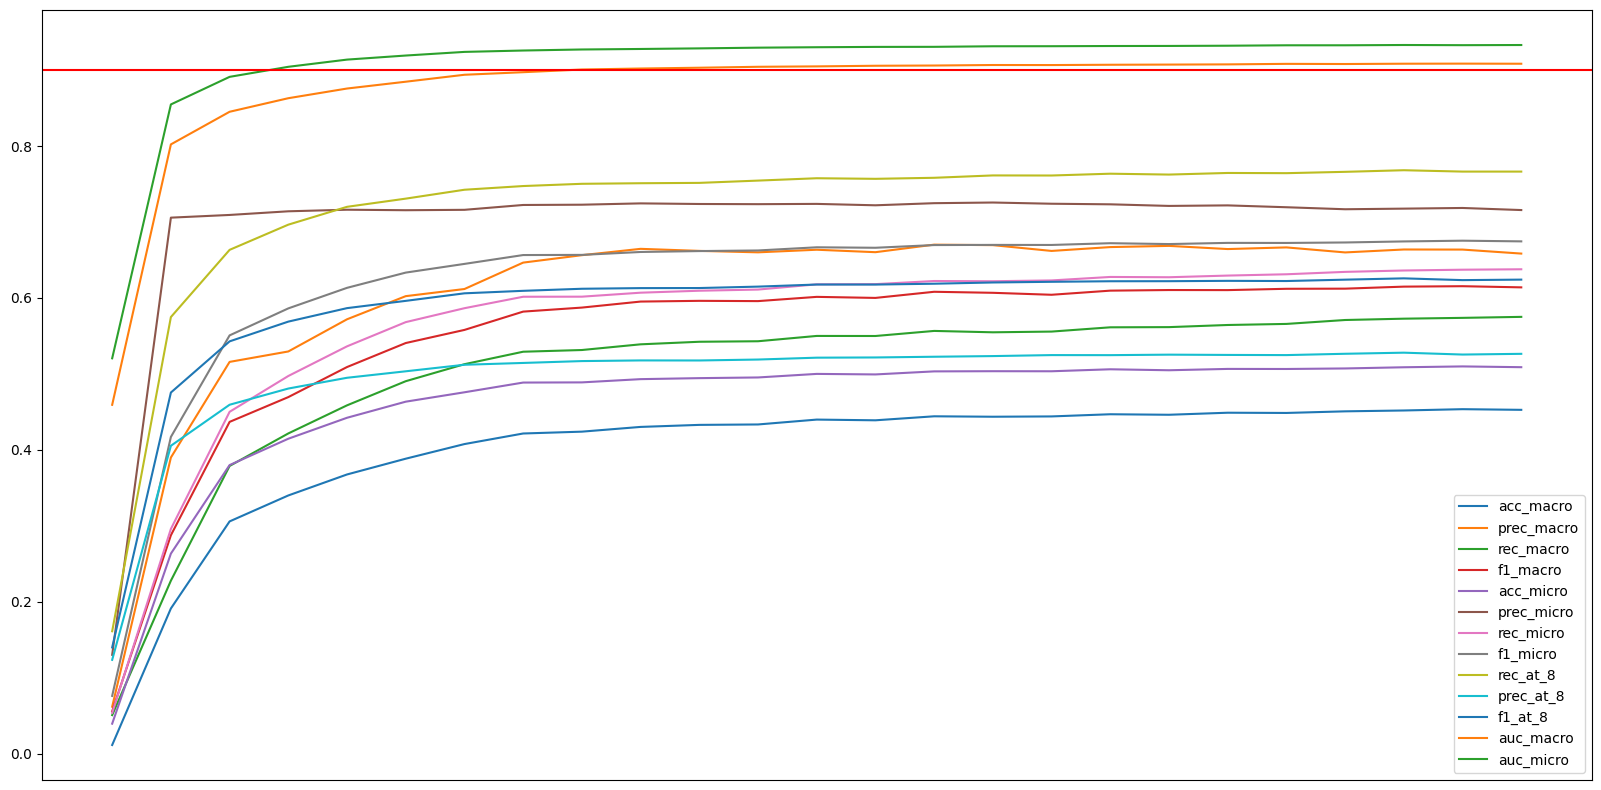

In [23]:
# Visualize the eval over the different training size
plt.figure(figsize=(20,10))
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False)

for key in intermediate_hist[0].keys():
    plt.plot([_ for _ in range(2_500//100)],[m[key] for m in intermediate_hist], label = key)
plt.legend()
plt.axhline(y=0.9, color='r', linestyle='-')
plt.xticks([_ for _ in range(2_500//100)])
plt.show()

In [16]:
limited_hist = eval_model(model = model,device = device,label_space = 50,data_loader  = test_loader)

---

In [ ]:
intermediate_history = []
eval_history = []
data_set_range = range(100,X_train.shape[0],200)
for training_size in data_set_range: # range(100,X_train.shape[0],500):
    # Build our new model
    model = ConvAttnPool(drop_out = 0.2,embed_table = embedding_table,vocab_size = vocab_size,
                num_of_filters = 15, label_space = 50, kernel_size = 5,embed_d = embed_size)
    model.to(device=device)

    # Create our loss and optimizer
    loss_module = torch.nn.BCEWithLogitsLoss()
    optimizer   = torch.optim.Adam(model.parameters(), lr = 0.0001, betas =  (0.9,0.99)) #(0.1,0.3)

    # Get a subset of the data
    indicies     = random.choices(population=[i for i in range(X_train.shape[0])], k = training_size)
    train_loader = DataLoader(TensorDataset(X_train[indicies],Y_train[indicies]) , batch_size = 16, shuffle = False)

    #
    hist, best_model, best_loss  \
                        = train_model(
                    model       = model,
                    device      = device,
                    optimizer   = optimizer,
                    data_loader = train_loader,
                    loss_module = loss_module,
                    num_epochs  = 250)

    model.load_state_dict(best_model)
    e_history = eval_model(model = model,
                           device = device,
                           data_loader=test_loader,
                           label_space=50)
    
    eval_history.append(e_history)
    intermediate_history.append(hist)

Runtime: 340.505s


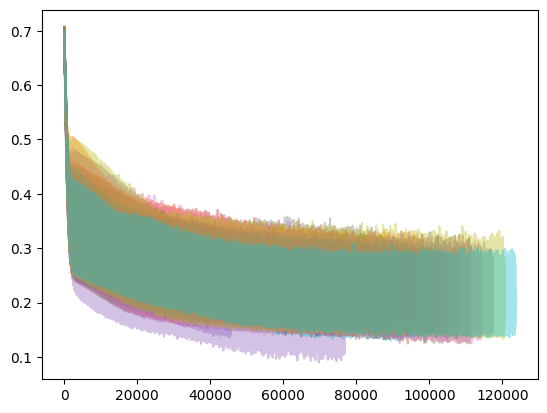

In [17]:
for h in intermediate_history:
    plt.plot(h,alpha = 0.4)
plt.show()

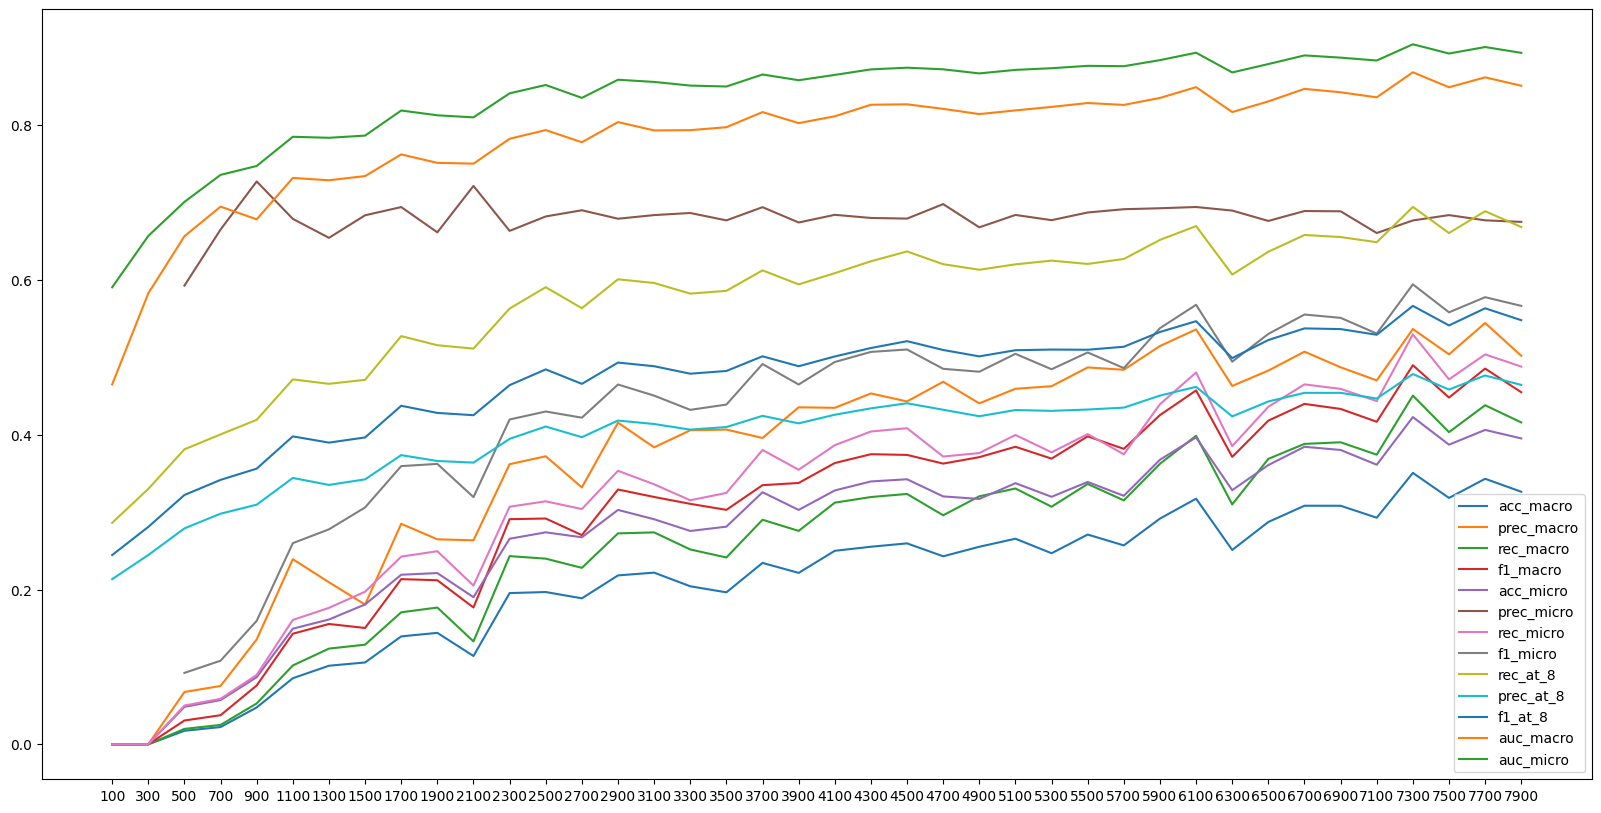

In [21]:
# Visualize the eval over the different training size
plt.figure(figsize=(20,10))
for key in eval_history[0].keys():
    plt.plot([_ for _ in data_set_range],[m[key] for m in eval_history], label = key)
plt.legend()
plt.xticks([_ for _ in data_set_range])
plt.show()

In [14]:
model.load_state_dict(best_model)
print(f'Smallest Loss: {best_loss}')

Smallest Loss: 0.10017991065979004


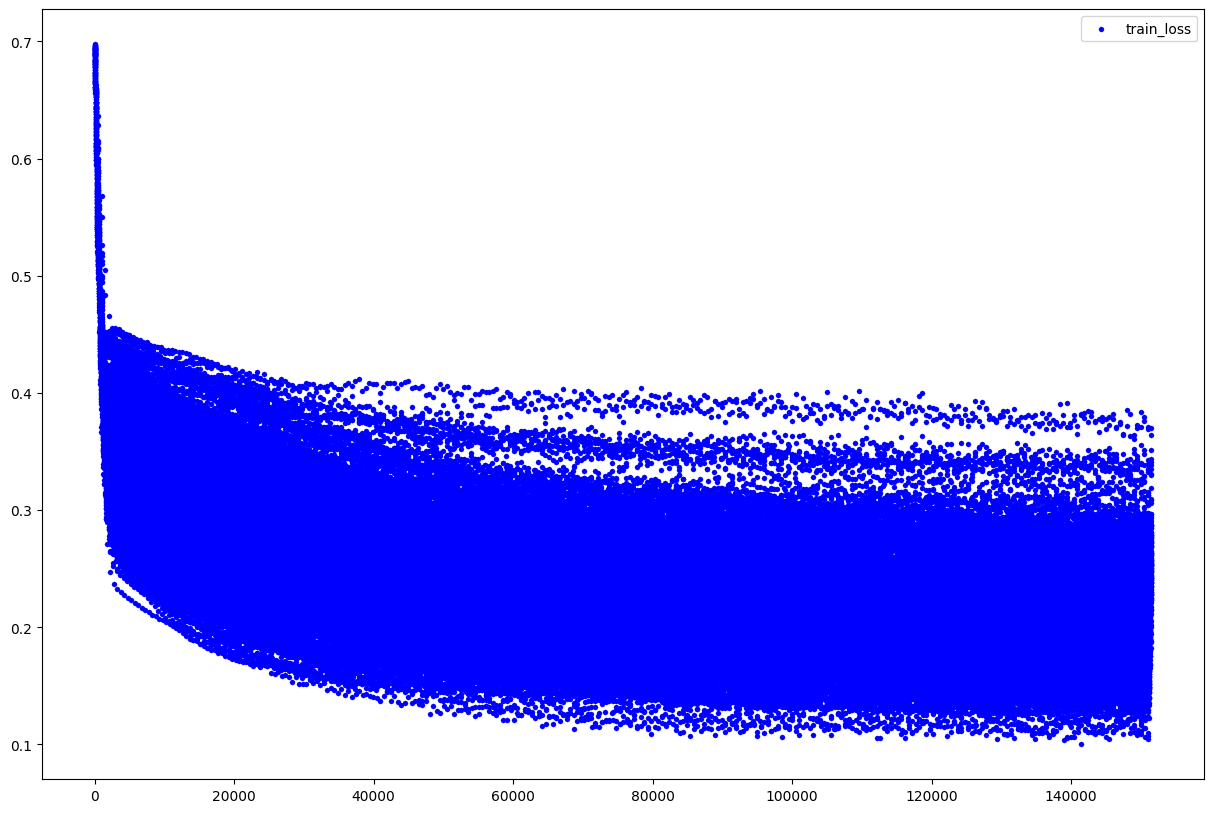

In [15]:
plt.figure(figsize=(15,10))
plt.scatter(y = hist,
            x = [_ for _ in range(len(hist))],
            alpha = 1, lw = 0.1, c = 'b', s = 14,label = 'train_loss')
plt.legend()
plt.show()

In [18]:
pprint(eval_model(model        = model,
           device       = device,
           label_space  = 50,
           data_loader  = train_loader))

eval_model(model        = model,
           device       = device,
           label_space  = 50,
           data_loader  = test_loader)

{'acc_macro': 0.351373397382982,
 'acc_micro': 0.4400597535167434,
 'auc_macro': 0.883869537436226,
 'auc_micro': 0.9201014427466174,
 'f1_at_8': 0.5791718737467311,
 'f1_macro': 0.48758094228105126,
 'f1_micro': 0.6111687413554634,
 'prec_at_8': 0.47805603768906524,
 'prec_macro': 0.5429485222178251,
 'prec_micro': 0.7058504720883133,
 'rec_at_8': 0.7345372287328077,
 'rec_macro': 0.4424606844438017,
 'rec_micro': 0.5388836864914306}


{'acc_macro': 0.3426978151369701,
 'prec_macro': 0.5322553159856138,
 'rec_macro': 0.4253702525878253,
 'f1_macro': 0.4728478136591244,
 'acc_micro': 0.41687877823735286,
 'prec_micro': 0.714422028353326,
 'rec_micro': 0.5002386179249785,
 'f1_micro': 0.588446640094313,
 'rec_at_8': 0.6973665016434555,
 'prec_at_8': 0.4809138230190862,
 'f1_at_8': 0.5692587465497237,
 'auc_macro': 0.8630469323405983,
 'auc_micro': 0.904333362323989}

Saving the model to model.tar

In [ ]:
# model_path = os.path.join(default_path,'model.tar')
# torch.save(model.state_dict(),f = model_path)

loading model weights

In [40]:
# model.load_state_dict(torch.load(os.path.join(default_path, 'model.tar'), weights_only=True))

---

In [18]:
def create_model():
    return ConvAttnPool(
            drop_out       = 0.2,
            embed_table   = embedding_table,
            vocab_size    = vocab_size,
            num_of_filters = 15, # Filters in paper -> 10
            label_space    = 50, 
            kernel_size    = 5,
            embed_d        = embed_size)

def load_client_data(client_idx: int, num_clients: int, idxs) -> TensorDataset:
    X = np.load('X_train.npy')
    Y = np.load('Y_train.npy')

    X = torch.from_numpy(X).long()
    Y = torch.from_numpy(Y).type(torch.float32)

    total_samples = X.size(0)
    # indices = list(range(client_idx, total_samples, num_clients))
    indices = [idx for idx, val in enumerate(idxs) if client_idx == val]
    X_client = X[indices]
    y_client = Y[indices]

    return TensorDataset(X_client, y_client)

Creating 2 scenarios  
1. Where a single clients trains on a subset
2. Where there are only two clinets

In [ ]:
X = np.load('X_train.npy')
total_samples = X.shape[0]
data_points = list(random.choices(population=[0,1,2],k = total_samples))

client_loaders = []
for client_idx in range(3):
    dataset = load_client_data(client_idx, 3, idxs=data_points)
    loader  = DataLoader(dataset, batch_size=64, shuffle=True)
    client_loaders.append(loader)

print(len(client_loaders))
train_loader = client_loaders[0]

3


In [44]:
loss_module = torch.nn.BCEWithLogitsLoss()

model = create_model()
optimizer   = torch.optim.Adam(model.parameters(), lr = 0.0001, betas =  (0.9,0.99)) #(0.1,0.3)

model.to(device)
hist, best_model, best_loss    = train_model(
                   model       = model,
                   device      = device,
                   optimizer   = optimizer,
                   data_loader = train_loader,
                   loss_module = loss_module,
                   num_epochs  = 300)
print(f'Lowest Loss: {best_loss}')

Runtime: 101.828s
Lowest Loss: 0.23509784042835236


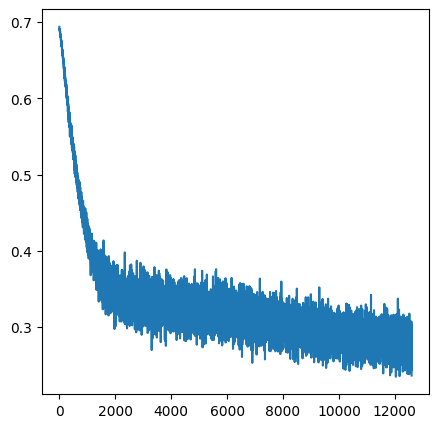

In [45]:
plt.figure(figsize=(5,5))
plt.plot(hist)
plt.show()

In [52]:
model.load_state_dict(best_model)

<All keys matched successfully>

In [54]:
single_client = eval_model(model=model,device=device, data_loader=test_loader, label_space=50)

---
### Simple Federated Learning Setup

In [19]:
def client_update(model  : nn.Module, train_loader: DataLoader, epochs : int = 1,lr: float = 0.0001, device : str = 'cpu') -> dict:
    model.to(device)
    model.train()
    # optimizer = optim.SGD(model.parameters(), lr=lr)
    optimizer   = torch.optim.Adam(model.parameters(), lr = 0.0001, betas =  (0.9,0.99)) #(0.1,0.3)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds, alpha = model(X_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()

    return copy.deepcopy(model.state_dict())

def server_aggregate(global_model: nn.Module, client_state_dicts: list) -> nn.Module:
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        stacked = torch.stack([client_dict[key].float() for client_dict in client_state_dicts], dim=0)
        global_dict[key] = torch.mean(stacked, dim=0)
    global_model.load_state_dict(global_dict)
    return global_model


In [59]:
num_clients  = 2
rounds       = 6
local_epochs = 100
batch_size   = 64

global_model = create_model()
history = []

X = np.load('X_train.npy')
total_samples = X.shape[0]
data_points = list(random.choices(population=[0,1,2],k = total_samples))

client_loaders = []
for client_idx in range(num_clients):
    dataset = load_client_data(client_idx, num_clients, idxs=data_points)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    client_loaders.append(loader)

for rnd in tqdm(range(rounds)):
    client_state_dicts = []
    for client_idx, loader in enumerate(client_loaders, 1):
        client_model  = create_model()
        client_model.load_state_dict(global_model.state_dict())
        updated_state = client_update( client_model,loader,epochs=local_epochs,device = device)
        client_state_dicts.append(updated_state)
    global_model = server_aggregate(global_model, client_state_dicts)
    global_model.to(device)
    history.append(eval_model(global_model,device,test_loader,label_space=50))

100%|██████████| 6/6 [05:49<00:00, 58.23s/it]


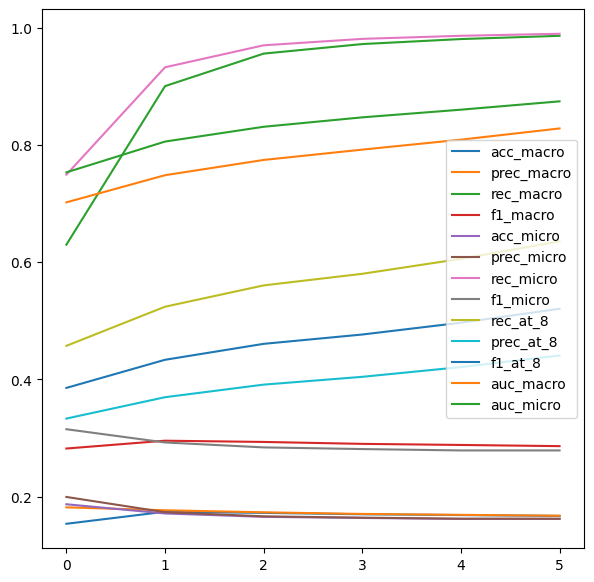

In [60]:
plt.figure(figsize=(7,7))
for key in history[0].keys():
    plt.plot([m[key] for m in history], label = key)
plt.legend()
plt.show()

In [61]:
model_path = os.path.join(default_path,'federated_model2.tar')
torch.save(global_model.state_dict(),f = model_path)
print('Saved Model!')

Saved Model!


In [20]:
global_model = create_model()
global_model.load_state_dict(torch.load(os.path.join(default_path, 'federated_model2.tar'), weights_only=True))
global_model.to(device)
global_model.eval()

ConvAttnPool(
  (embed): Embedding(150854, 100, padding_idx=150853)
  (conv): Conv1d(100, 15, kernel_size=(5,), stride=(1,), padding=(2,))
  (U): Linear(in_features=15, out_features=50, bias=True)
  (final): Linear(in_features=15, out_features=50, bias=True)
  (embed_drop): Dropout(p=0.2, inplace=False)
)

In [21]:
pprint(eval_model(model = global_model,
           device       = device,
           label_space  = 50,
           data_loader  = train_loader))

pprint(eval_model(model = global_model,
           device       = device,
           label_space  = 50,
           data_loader  = test_loader))

{'acc_macro': 0.1620504368181099,
 'acc_micro': 0.1553439707036359,
 'auc_macro': 0.8477267451545203,
 'auc_micro': 0.8938567751141872,
 'f1_at_8': 0.5413786793362466,
 'f1_macro': 0.27877991154699006,
 'f1_micro': 0.268913803408741,
 'prec_at_8': 0.44826923076923075,
 'prec_macro': 0.1622286541392142,
 'prec_micro': 0.15550504838912396,
 'rec_at_8': 0.683307672496393,
 'rec_macro': 0.99011968911507,
 'rec_micro': 0.9933761541549578}
{'acc_macro': 0.1669946880292581,
 'acc_micro': 0.16191859557054947,
 'auc_macro': 0.8279975959136969,
 'auc_micro': 0.8742392357203013,
 'f1_at_8': 0.5203815647076587,
 'f1_macro': 0.2860498428656045,
 'f1_micro': 0.2787090183216163,
 'prec_at_8': 0.4406448814343551,
 'prec_macro': 0.1672908241544588,
 'prec_micro': 0.1621972589023093,
 'rec_at_8': 0.6353512445813333,
 'rec_macro': 0.9860237739998144,
 'rec_micro': 0.9895008113009449}


In [22]:
def compare_metric(dict1: dict, dict2: dict, metric: str) -> str:
    """
    Compares the given metric between two dictionaries and returns a color-coded percent difference.
    
    Parameters:
    - dict1: First dictionary of metrics (e.g., baseline)
    - dict2: Second dictionary of metrics (e.g., new model)
    - metric: The name of the metric to compare
    
    Returns:
    - A string with color-coded percent difference:
        Green:  >5% improvement
        Red:    >5% drop
        Yellow: ~ no significant change
    """
    if metric not in dict1 or metric not in dict2:
        return f"\033[91mError:\033[0m Metric '{metric}' not found in both dictionaries."

    val1 = dict1[metric]
    val2 = dict2[metric]

    if val1 == 0:
        return f"\033[91mError:\033[0m Cannot compute percent difference from zero baseline."

    percent_diff = ((val2 - val1) / abs(val1)) * 100

    # Determine color
    if percent_diff > 5:
        color = "\033[92m"  # Green
    elif percent_diff < -5:
        color = "\033[91m"  # Red
    else:
        color = "\033[93m"  # Yellow

    return f"{color}{metric}: {percent_diff:.2f}% change ({val1:.4f} → {val2:.4f})\033[0m"


In [23]:
central_model = create_model()
central_model.load_state_dict(torch.load(os.path.join(default_path, 'model.tar'), weights_only=True))
central_model.to(device)

ConvAttnPool(
  (embed): Embedding(150854, 100, padding_idx=150853)
  (conv): Conv1d(100, 15, kernel_size=(5,), stride=(1,), padding=(2,))
  (U): Linear(in_features=15, out_features=50, bias=True)
  (final): Linear(in_features=15, out_features=50, bias=True)
  (embed_drop): Dropout(p=0.2, inplace=False)
)

In [64]:
federated_test = \
       eval_model(model = global_model,
           device       = device,
           label_space  = 50,
           data_loader  = test_loader)

In [24]:
centralized_test = \
       eval_model(model = central_model,
           device       = device,
           label_space  = 50,
           data_loader  = test_loader)

---

In [25]:
# Comparing the history of a limited model
for key in centralized_test.keys():
    print(compare_metric(centralized_test,limited_hist,key),'<br>')

acc_macro: 1.47% change (0.3427 → 0.3477) <br>
prec_macro: 10.79% change (0.5323 → 0.5897) <br>
rec_macro: 3.76% change (0.4254 → 0.4414) <br>
f1_macro: 6.77% change (0.4728 → 0.5049) <br>
acc_micro: -3.64% change (0.4169 → 0.4017) <br>
prec_micro: -5.92% change (0.7144 → 0.6721) <br>
rec_micro: -0.13% change (0.5002 → 0.4996) <br>
f1_micro: -2.60% change (0.5884 → 0.5731) <br>
rec_at_8: -2.32% change (0.6974 → 0.6812) <br>
prec_at_8: -2.51% change (0.4809 → 0.4688) <br>
f1_at_8: -2.43% change (0.5693 → 0.5554) <br>
auc_macro: -0.65% change (0.8630 → 0.8574) <br>
auc_micro: -0.96% change (0.9043 → 0.8957) <br>


---

### Final Comparison between federated and centralized model

In [65]:
for key in federated_test.keys():
    print(compare_metric(centralized_test,federated_test,key),'<br>')

acc_macro: -51.27% change (0.3427 → 0.1670) <br>
prec_macro: -68.57% change (0.5323 → 0.1673) <br>
rec_macro: 131.80% change (0.4254 → 0.9860) <br>
f1_macro: -39.50% change (0.4728 → 0.2860) <br>
acc_micro: -61.16% change (0.4169 → 0.1619) <br>
prec_micro: -77.30% change (0.7144 → 0.1622) <br>
rec_micro: 97.81% change (0.5002 → 0.9895) <br>
f1_micro: -52.64% change (0.5884 → 0.2787) <br>
rec_at_8: -8.89% change (0.6974 → 0.6354) <br>
prec_at_8: -8.37% change (0.4809 → 0.4406) <br>
f1_at_8: -8.59% change (0.5693 → 0.5204) <br>
auc_macro: -4.06% change (0.8630 → 0.8280) <br>
auc_micro: -3.33% change (0.9043 → 0.8742) <br>


In [ ]:
base_line = \
{'acc_macro' : 0.17739008193602349,
 'acc_micro' : 0.17171046075142013,
 'auc_macro' : 0.8301769033903681,
 'auc_micro' : 0.8757615786957142,
 'f1_at_8'   : 0.5242679111738379,
 'f1_macro'  : 0.30106059183291545,
 'f1_micro'  : 0.29309367203447495,
 'prec_at_8' : 0.44548872180451127,
 'prec_macro': 0.17779269561330902,
 'prec_micro': 0.17210781294221453,
 'rec_at_8'  : 0.636894929021881,
 'rec_macro' : 0.9816886033531064,
 'rec_micro' : 0.986732843371194}

In [66]:
for key in centralized_test.keys():
    print(compare_metric(centralized_test,single_client,key),'<br>')

acc_macro: -71.84% change (0.3427 → 0.0965) <br>
prec_macro: -55.11% change (0.5323 → 0.2389) <br>
rec_macro: -72.66% change (0.4254 → 0.1163) <br>
f1_macro: -66.92% change (0.4728 → 0.1564) <br>
acc_micro: -60.64% change (0.4169 → 0.1641) <br>
prec_micro: -2.99% change (0.7144 → 0.6931) <br>
rec_micro: -64.63% change (0.5002 → 0.1770) <br>
f1_micro: -52.09% change (0.5884 → 0.2819) <br>
rec_at_8: -33.96% change (0.6974 → 0.4605) <br>
prec_at_8: -29.93% change (0.4809 → 0.3370) <br>
f1_at_8: -31.63% change (0.5693 → 0.3892) <br>
auc_macro: -15.84% change (0.8630 → 0.7263) <br>
auc_micro: -12.95% change (0.9043 → 0.7872) <br>
